# Parte II. Similitud: shingling, Jaccard, MinHash y LSH

**Integrantes:** Ricardo Amiel Acuña Villogas, Juan Leibniz Aquino Espinoza y Camilo Ernesto Soto Cristóbal.

**Pregunta concreta.** Hay procesos cuyo objeto contractual es prácticamente el mismo texto repetido entre entidades, y proveedores que aparecen como distintos siendo la misma empresa. Ninguna de las dos cosas se detecta comparando todos los pares: con 177.398 procesos son más de quince mil millones de comparaciones.

**Spark es obligatorio en esta parte.** Las firmas y el agrupamiento por bandas corren sobre RDD, que es donde el estilo imperativo gana al declarativo.

El porqué de cada elección está en docs/JUSTIFICACION.md, sección Parte II.

In [ ]:
import sys, time
from pathlib import Path

# Los ayudantes del proyecto viven en notebooks/scripts. Se importan por
# nombre, no con asterisco, para que quede claro de donde sale cada uno.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "notebooks" / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import Window
from pyspark.sql import functions as F

from scripts.helpers import (PARQUET, FIGS, ARTEFACTOS, FIGURAS, PALETA,
                     AZUL, ROJO, VERDE, MORADO, TEAL, TINTA, SUAVE, fmt,
                     abrir_spark, cronometro, medir, figura, exportar,
                     barras_h, lineas, barras_agrupadas, mapa_calor, lorenz, gini)
from scripts.algoritmos import (shingles, jaccard, MinHash, bandas,
                        prob_candidato, umbral_lsh, simhash, hamming)

pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 64)


spark = abrir_spark("P2-Similitud")
datos = spark.read.parquet(str(PARQUET))
datos.createOrReplaceTempView("contrataciones")
print(f"{datos.count():,} procesos disponibles")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/04 21:02:13 WARN Utils: Your hostname, germain-ThinkPad-E15-Gen-2, resolves to a loopback address: 127.0.1.1; using 192.168.1.27 instead (on interface wlp0s20f3)
26/10/04 21:02:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/04 21:02:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


177,398 procesos disponibles


## 1. Dos representaciones como conjunto

El dataset ofrece dos y compararlas es en sí mismo un resultado. Los shingles del objeto capturan el texto tal como lo digitó cada entidad; el conjunto de códigos CUBSO ya viene normalizado por el catálogo del Estado pero es mucho más grueso.

In [2]:
# Muestra de trabajo: es sobre ella que se puede calcular Jaccard exacta para
# todos los pares, que es la verdad de referencia contra la que se mide todo.
N = 2000
muestra = (datos.filter("length(objeto) > 60 AND adjudicado")
           .select("ocid", "objeto", "items", "proveedor_nombre", "comprador_nombre", "monto_pen")
           .orderBy(F.hash("ocid")).limit(N).toPandas())
print(f"muestra de {len(muestra):,} procesos, {N*(N-1)//2:,} pares posibles")
muestra.objeto.str.len().describe().round(0).to_frame("largo del objeto en caracteres").T

muestra de 2,000 procesos, 1,999,000 pares posibles


,count,mean,std,min,25%,50%,75%,max
largo del objeto en caracteres,2000.0,199.0,80.0,61.0,134.0,195.0,257.0,590.0



Lectura de f16_calibracion_k
Las dos curvas bajan juntas, así que ninguna métrica sobre pares aleatorios tiene un máximo interior y buscarlo sería fabricar un resultado. Lo que se fija es un criterio: k debe ser lo bastante grande para que dos objetos no relacionados no compartan casi nada. Con k = 3 el fondo está en 0.138, es decir que dos textos cualesquiera ya se parecen un 14 % solo por ser español administrativo. El primer k que deja el fondo por debajo de 0,02 es k = 9, con fondo 0.0114 y señal 0.115. Subir más solo recorta señal y gasta memoria. La elección no es crítica: el barrido de LSH de la sección 4 da resultados muy parecidos con k = 7 y k = 11.



,k,shingles_por_doc,fondo_mediana,senal_p99
0,3,153.7,0.1384,0.3010
1,5,179.4,0.0549,0.2023
2,7,186.0,0.0247,0.1490
3,9,187.1,0.0114,0.1152
4,11,186.5,0.0047,0.0911
5,13,185.3,0.0000,0.0733


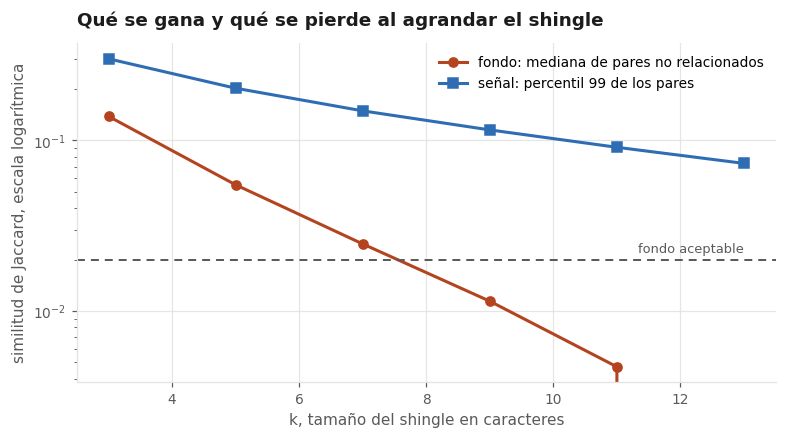

In [3]:
# Calibracion de k. No hay un optimo que salga de los datos: al subir k el fondo
# de pares no relacionados cae, pero la senal de los pares parecidos tambien.
# Lo que se fija es un criterio, y el del curso es que dos documentos no
# relacionados no compartan practicamente nada.
filas = []
for k in (3, 5, 7, 9, 11, 13):
    conj = [shingles(t, k) for t in muestra.objeto.head(400)]
    sims = np.array([jaccard(conj[i], conj[j])
                     for i in range(400) for j in range(i + 1, 400)])
    filas.append({"k": k, "shingles_por_doc": round(float(np.mean([len(c) for c in conj])), 1),
                  "fondo_mediana": round(float(np.median(sims)), 4),
                  "senal_p99": round(float(np.percentile(sims, 99)), 4)})
calib = pd.DataFrame(filas)
exportar(calib, "p2_calibracion_k", "Fondo y senal de Jaccard segun el tamano del shingle")

fig, ax = plt.subplots(figsize=(8.2, 4))
ax.plot(calib.k, calib.fondo_mediana, "o-", color=ROJO, lw=2,
        label="fondo: mediana de pares no relacionados")
ax.plot(calib.k, calib.senal_p99, "s-", color=AZUL, lw=2,
        label="señal: percentil 99 de los pares")
ax.axhline(0.02, color=SUAVE, lw=1.3, ls=(0, (4, 3)))
ax.text(calib.k.max(), 0.022, "fondo aceptable", ha="right", fontsize=8.5, color=SUAVE)
ax.set_yscale("log"); ax.set_xlabel("k, tamaño del shingle en caracteres")
ax.set_ylabel("similitud de Jaccard, escala logarítmica")
ax.set_title("Qué se gana y qué se pierde al agrandar el shingle", loc="left", pad=12)
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend()

elegible = calib[calib.fondo_mediana < 0.02]
K = int(elegible.k.min()) if len(elegible) else 9
f0 = calib[calib.k == 3].iloc[0]; fk = calib[calib.k == K].iloc[0]
figura(fig, "f16_calibracion_k", f"""
Las dos curvas bajan juntas, así que ninguna métrica sobre pares aleatorios tiene un máximo
interior y buscarlo sería fabricar un resultado. Lo que se fija es un criterio: k debe ser lo
bastante grande para que dos objetos no relacionados no compartan casi nada. Con k = 3 el fondo
está en {f0.fondo_mediana:.3f}, es decir que dos textos cualesquiera ya se parecen un
{100*f0.fondo_mediana:.0f} % solo por ser español administrativo. El primer k que deja el fondo
por debajo de 0,02 es k = {K}, con fondo {fk.fondo_mediana:.4f} y señal {fk.senal_p99:.3f}.
Subir más solo recorta señal y gasta memoria. La elección no es crítica: el barrido de LSH de la
sección 4 da resultados muy parecidos con k = {K - 2} y k = {K + 2}.""")
calib

In [4]:
muestra["shingles"] = [shingles(t, K) for t in muestra.objeto]
muestra["cubso"] = [set(x) for x in muestra["items"]]

comparacion_rep = pd.DataFrame([
    {"representacion": f"shingles del objeto, k={K}",
     "elementos_medios": round(muestra.shingles.map(len).mean(), 1),
     "universo": len(set().union(*muestra.shingles)),
     "docs_vacios": int((muestra.shingles.map(len) == 0).sum())},
    {"representacion": "conjunto de codigos CUBSO",
     "elementos_medios": round(muestra.cubso.map(len).mean(), 2),
     "universo": len(set().union(*muestra.cubso)),
     "docs_vacios": int((muestra.cubso.map(len) == 0).sum())}])
exportar(comparacion_rep, "p2_representaciones", "Las dos representaciones como conjunto")
comparacion_rep

,representacion,elementos_medios,universo,docs_vacios
0,"shingles del objeto, k=9",186.90,137412,0
1,conjunto de codigos CUBSO,0.94,654,270


La tabla decide cuál se usa. El conjunto CUBSO tiene menos de un elemento por proceso en promedio y muchos procesos vacíos, así que no sostiene una similitud discriminante. Los shingles del objeto sí. El CUBSO se reserva para la Parte V, donde la canasta se redefine por entidad y mes.

## 2. Jaccard exacta, la verdad de referencia

Sobre la muestra se calculan los dos millones de pares con álgebra dispersa en lugar de un bucle: una matriz binaria de documentos por shingles, y la intersección de todos los pares sale de un solo producto matricial.

In [5]:
from scipy.sparse import csr_matrix

vocab = {s: i for i, s in enumerate(sorted(set().union(*muestra.shingles)))}
filas_idx = [i for i, c in enumerate(muestra.shingles) for _ in c]
cols_idx = [vocab[s] for c in muestra.shingles for s in c]
M = csr_matrix((np.ones(len(filas_idx), dtype=np.int32), (filas_idx, cols_idx)),
               shape=(len(muestra), len(vocab)))

with cronometro("Jaccard exacta sobre todos los pares"):
    inter = (M @ M.T).toarray()
    tam = np.array(M.sum(axis=1)).ravel()
    union = tam[:, None] + tam[None, :] - inter
    J = np.divide(inter, union, out=np.zeros_like(inter, dtype=float), where=union > 0)
    np.fill_diagonal(J, 0.0)

iu = np.triu_indices(len(muestra), 1)
j_exacta = J[iu]
print(f"{len(j_exacta):,} pares  |  Jaccard media {j_exacta.mean():.4f}  "
      f"max {j_exacta.max():.4f}  pares con J>=0.5: {(j_exacta>=0.5).sum():,}")

Jaccard exacta sobre todos los pares: 0.14 s
1,999,000 pares  |  Jaccard media 0.0207  max 1.0000  pares con J>=0.5: 42



Lectura de f17_distribucion_jaccard
El eje vertical va en logaritmo porque si no, la primera barra aplasta todo lo demás. La enorme mayoría de los pares tiene similitud casi nula, que es lo esperable y justamente lo que hace viable LSH: solo 42 pares de 1,999,000 superan 0,5, es decir el 0.002 %. Comparar todos los pares para encontrar esa fracción es desperdicio, y ese desperdicio es lo que LSH elimina.



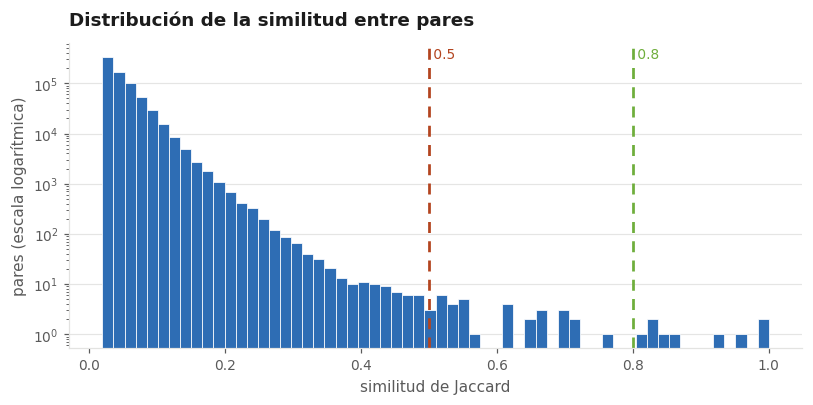

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.hist(j_exacta[j_exacta > 0.02], bins=60, color=AZUL, edgecolor="white", linewidth=.5)
ax.set_yscale("log"); ax.grid(axis="y", alpha=.9); ax.set_axisbelow(True)
ax.set_xlabel("similitud de Jaccard"); ax.set_ylabel("pares (escala logarítmica)")
ax.set_title("Distribución de la similitud entre pares", loc="left", pad=12)
for u, c in ((0.5, ROJO), (0.8, VERDE)):
    ax.axvline(u, color=c, lw=1.8, ls=(0, (4, 3)))
    ax.text(u, ax.get_ylim()[1] * .5, f" {u}", color=c, fontsize=9)
figura(fig, "f17_distribucion_jaccard", f"""
El eje vertical va en logaritmo porque si no, la primera barra aplasta todo lo demás. La enorme
mayoría de los pares tiene similitud casi nula, que es lo esperable y justamente lo que hace
viable LSH: solo {(j_exacta>=0.5).sum():,} pares de {len(j_exacta):,} superan 0,5, es decir el
{100*(j_exacta>=0.5).mean():.3f} %. Comparar todos los pares para encontrar esa fracción es
desperdicio, y ese desperdicio es lo que LSH elimina.""")

## 3. MinHash

La propiedad que lo sostiene: para una permutación aleatoria, la probabilidad de que dos conjuntos compartan el mínimo es exactamente su Jaccard. Con n funciones, la fracción de coincidencias estima Jaccard con error del orden de uno sobre la raíz de n.


Lectura de f18_error_minhash
El error observado sigue la cota teórica y baja como uno sobre la raíz de n: cuadruplicar las funciones hash solo divide el error entre dos. Pasar de 32 a 256 hashes baja el error de 0.0142 a 0.0052, a cambio de multiplicar por ocho la memoria de la firma. Se eligen 128 hashes: el error de 0.0072 es muy inferior al ancho de las bandas de decisión de LSH, así que gastar más no compra nada.



,n_hashes,error_medio,cota_1_sobre_raiz_n,bytes_por_doc
0,32,0.01420,0.1768,256
1,64,0.01092,0.1250,512
2,128,0.00715,0.0884,1024
3,256,0.00520,0.0625,2048


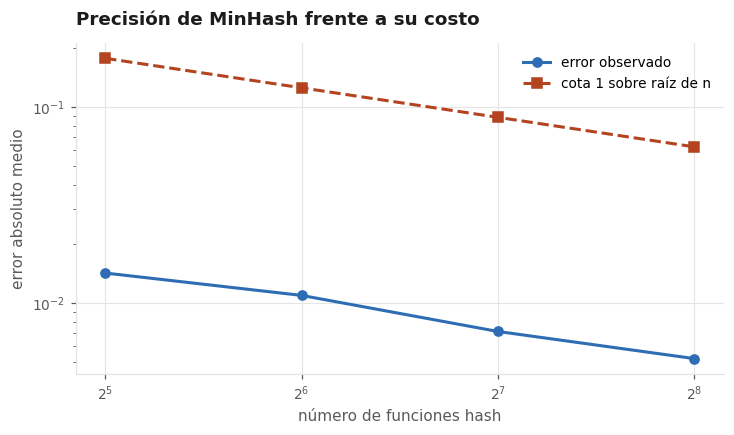

In [7]:
errores = []
for n_hash in (32, 64, 128, 256):
    mh = MinHash(n_hash, semilla=7)
    firmas = np.vstack([mh.firma(c) for c in muestra.shingles.head(400)])
    est = np.array([(firmas[i] == firmas[j]).mean()
                    for i in range(400) for j in range(i + 1, 400)])
    real = J[:400, :400][np.triu_indices(400, 1)]
    errores.append({"n_hashes": n_hash,
                    "error_medio": round(float(np.abs(est - real).mean()), 5),
                    "cota_1_sobre_raiz_n": round(1 / np.sqrt(n_hash), 4),
                    "bytes_por_doc": n_hash * 8})
err = pd.DataFrame(errores)
exportar(err, "p2_error_minhash", "Error de estimacion de MinHash segun el numero de hashes")

fig, ax = plt.subplots(figsize=(7.6, 3.9))
ax.plot(err.n_hashes, err.error_medio, "o-", color=AZUL, lw=2, label="error observado")
ax.plot(err.n_hashes, err.cota_1_sobre_raiz_n, "s--", color=ROJO, lw=2,
        label="cota 1 sobre raíz de n")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("número de funciones hash"); ax.set_ylabel("error absoluto medio")
ax.set_title("Precisión de MinHash frente a su costo", loc="left", pad=12)
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend()
figura(fig, "f18_error_minhash", f"""
El error observado sigue la cota teórica y baja como uno sobre la raíz de n: cuadruplicar las
funciones hash solo divide el error entre dos. Pasar de 32 a 256 hashes baja el error de
{err.error_medio.iloc[0]:.4f} a {err.error_medio.iloc[-1]:.4f}, a cambio de multiplicar por
ocho la memoria de la firma. Se eligen 128 hashes: el error de {err[err.n_hashes==128].error_medio.iloc[0]:.4f}
es muy inferior al ancho de las bandas de decisión de LSH, así que gastar más no compra nada.""")
err

## 4. LSH por bandas, en Spark

La firma se parte en b bandas de r filas. Dos documentos son candidatos si coinciden en al menos una banda, y solo esos se verifican con Jaccard exacta. La probabilidad de que un par con similitud s sea candidato es uno menos (uno menos s elevado a r) elevado a b, que es la curva S.

Una aclaración que decide cómo se mide todo lo que sigue. **LSH es un generador de candidatos, no un clasificador.** Su salida pasa después por una verificación exacta que elimina todos los falsos positivos, de modo que la precisión antes de verificar no es una medida de calidad: es una medida de cuánto trabajo queda por hacer. Las dos cifras que importan son el recall, porque un par perdido aquí se pierde para siempre, y el número de candidatos, porque es el costo de la verificación.

Aquí es donde los RDD ganan al estilo declarativo: el agrupamiento por bandas es un flatMap seguido de un groupByKey, y expresarlo en SQL sería forzado.

In [8]:
from itertools import combinations

N_HASH = 128
mh = MinHash(N_HASH, semilla=7)
mh_b = spark.sparkContext.broadcast(mh)

docs = spark.sparkContext.parallelize(list(enumerate(muestra.shingles)), 8)
firmas = docs.map(lambda t: (t[0], mh_b.value.firma(t[1]))).cache()
print(f"{firmas.count():,} firmas de {N_HASH} enteros, en {firmas.getNumPartitions()} particiones")


def candidatos_lsh(firmas_rdd, b, r):
    """Agrupa por banda y devuelve los pares que caen en el mismo bucket.

    La firma se recorta a los primeros b por r valores. Hace falta porque no
    todo r divide a 128: con r=3 salen 42 bandas y sobran dos posiciones, que
    simplemente no se usan.
    """
    usados = b * r
    return (firmas_rdd
            .flatMap(lambda t: [((i, bh), t[0])
                                for i, bh in enumerate(bandas(t[1][:usados], b, r))])
            .groupByKey()
            .filter(lambda kv: 2 <= len(kv[1]) <= 400)   # un bucket enorme no informa
            .flatMap(lambda kv: combinations(sorted(kv[1]), 2))
            .distinct())

2,000 firmas de 128 enteros, en 8 particiones


In [9]:
UMBRAL = 0.3
reales = {(i, j) for i, j in zip(*np.where(J >= UMBRAL)) if i < j}
print(f"verdad de referencia: {len(reales):,} pares con Jaccard >= {UMBRAL} "
      f"de {len(j_exacta):,} posibles")


def evaluar(cand, etiqueta, verificado=False, **extra):
    """Mide un generador de candidatos.

    recall: de los pares verdaderos, cuantos llegan a la etapa de verificacion.
    candidatos: cuantos pares hay que verificar, que es el costo real.
    Si la salida ya viene verificada, se indica para no comparar peras con manzanas.
    """
    aciertos = len(cand & reales)
    return {"configuracion": etiqueta, "salida_verificada": verificado,
            "candidatos": len(cand),
            # Falsos positivos: pares propuestos que no superan el umbral. Los
            # elimina la verificacion exacta, asi que son costo y no error.
            "falsos_positivos": len(cand) - aciertos,
            # Falsos negativos: pares verdaderos que LSH nunca propuso. Estos si
            # son error, porque se pierden para siempre.
            "falsos_negativos": len(reales) - aciertos,
            "recall": round(aciertos / len(reales), 4) if reales else 0.0,
            "precision": round(aciertos / len(cand), 4) if cand else 0.0,
            "pct_pares_a_verificar": round(100 * len(cand) / len(j_exacta), 3), **extra}


resultados = []
for r in (1, 2, 3, 4, 5, 6, 8):
    b = N_HASH // r
    cand = set(candidatos_lsh(firmas, b, r).collect())
    resultados.append(evaluar(cand, f"b={b}, r={r}", b=b, r=r,
                              umbral_teorico=round(umbral_lsh(b, r), 3)))
lsh = pd.DataFrame(resultados)
exportar(lsh, "p2_barrido_lsh",
         "Falsos positivos, falsos negativos, recall y costo de verificacion por banda y fila")
lsh

verdad de referencia: 263 pares con Jaccard >= 0.3 de 1,999,000 posibles


,configuracion,salida_verificada,candidatos,falsos_positivos,falsos_negativos,recall,precision,pct_pares_a_verificar,b,r,umbral_teorico
0,"b=128, r=1",False,993962,993699,0,1.0000,0.0003,49.723,128,1,0.008
1,"b=64, r=2",False,171259,170997,1,0.9962,0.0015,8.567,64,2,0.125
2,"b=42, r=3",False,32337,32106,32,0.8783,0.0071,1.618,42,3,0.288
3,"b=32, r=4",False,1177,1051,137,0.4791,0.1071,0.059,32,4,0.420
4,"b=25, r=5",False,139,64,188,0.2852,0.5396,0.007,25,5,0.525
5,"b=21, r=6",False,59,18,222,0.1559,0.6949,0.003,21,6,0.602
6,"b=16, r=8",False,24,0,239,0.0913,1.0000,0.001,16,8,0.707



Lectura de f19_curva_s
Cada configuración es una decisión sobre qué cuenta como parecido, y la curva la hace explícita. Con muchas bandas y pocas filas sube temprano: atrapa todo lo parecido y también mucha basura. Con pocas bandas y muchas filas sube tarde: casi no hay falsos positivos pero se escapan pares legítimos. El umbral teórico (1/b) elevado a 1/r marca dónde la curva cambia de concavidad, y conviene no confundirlo con el punto medio: ahí la probabilidad no es un medio sino alrededor de 0,63, que es 1 menos 1 sobre e.



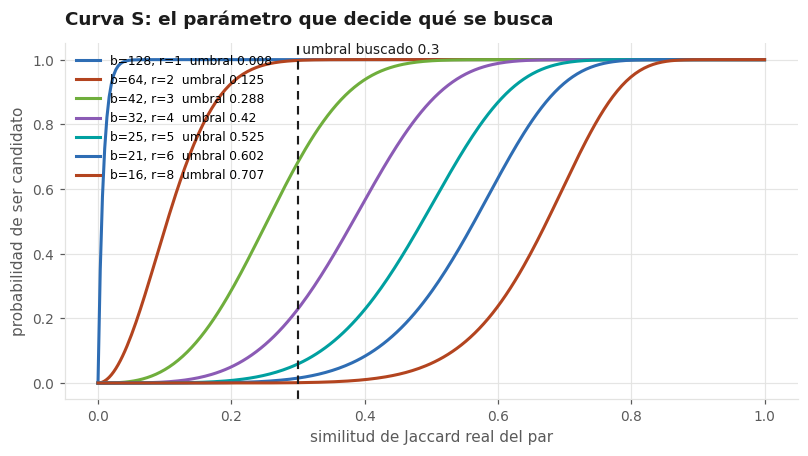

In [10]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
s = np.linspace(0, 1, 300)
for i, f in lsh.iterrows():
    ax.plot(s, prob_candidato(s, int(f.b), int(f.r)), lw=2, color=PALETA[i % 5],
            label=f"b={int(f.b)}, r={int(f.r)}  umbral {f.umbral_teorico}")
ax.axvline(UMBRAL, color=TINTA, lw=1.4, ls=(0, (4, 3)))
ax.text(UMBRAL, 1.02, f" umbral buscado {UMBRAL}", fontsize=9, color=TINTA)
ax.set_xlabel("similitud de Jaccard real del par")
ax.set_ylabel("probabilidad de ser candidato")
ax.set_title("Curva S: el parámetro que decide qué se busca", loc="left", pad=12)
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend(fontsize=8, loc="upper left")
figura(fig, "f19_curva_s", f"""
Cada configuración es una decisión sobre qué cuenta como parecido, y la curva la hace explícita.
Con muchas bandas y pocas filas sube temprano: atrapa todo lo parecido y también mucha basura.
Con pocas bandas y muchas filas sube tarde: casi no hay falsos positivos pero se escapan pares
legítimos. El umbral teórico (1/b) elevado a 1/r marca dónde la curva cambia de concavidad, y
conviene no confundirlo con el punto medio: ahí la probabilidad no es un medio sino alrededor de
0,63, que es 1 menos 1 sobre e.""")


Lectura de f20_recall_vs_costo
Los dos errores no cuestan lo mismo y por eso la figura usa recall frente a costo. Un falso positivo lo elimina la verificación exacta posterior, de modo que es trabajo y no error; un falso negativo se pierde para siempre. La configuración b=64 por r=2 deja 1 falsos negativos de 263 pares verdaderos, con recall 0.996, y arrastra 170,997 falsos positivos, que es el 8.57 % de los pares a verificar. En el otro extremo, b=16 por r=8 baja los falsos positivos a 0 pero deja 239 falsos negativos, perdiendo la mayoría de lo que importa.



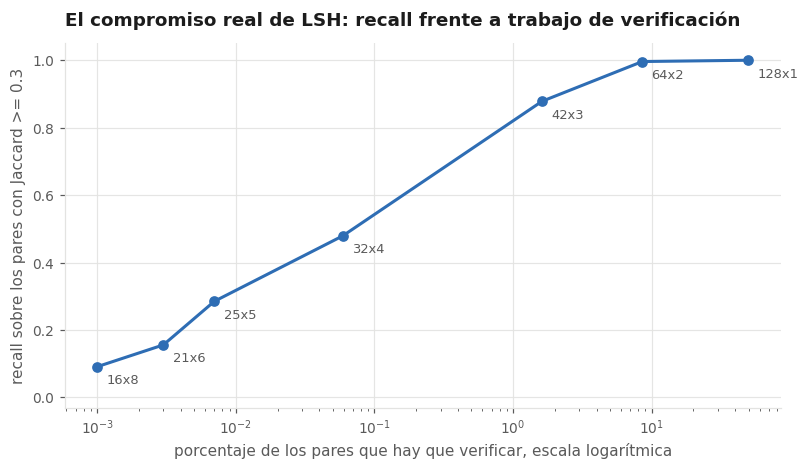

In [11]:
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.plot(lsh.pct_pares_a_verificar, lsh.recall, "o-", color=AZUL, lw=2)
for _, f in lsh.iterrows():
    ax.annotate(f"{int(f.b)}x{int(f.r)}", (f.pct_pares_a_verificar, f.recall),
                textcoords="offset points", xytext=(6, -11), fontsize=8.5, color=SUAVE)
ax.set_xscale("log")
ax.set_xlabel("porcentaje de los pares que hay que verificar, escala logarítmica")
ax.set_ylabel(f"recall sobre los pares con Jaccard >= {UMBRAL}")
ax.set_ylim(-0.03, 1.05)
ax.set_title("El compromiso real de LSH: recall frente a trabajo de verificación", loc="left", pad=12)
ax.grid(alpha=.9); ax.set_axisbelow(True)

viables = lsh[lsh.recall >= 0.95]
mejor = viables.loc[viables.candidatos.idxmin()] if len(viables) else lsh.loc[lsh.recall.idxmax()]
peor = lsh.iloc[-1]
figura(fig, "f20_recall_vs_costo", f"""
Los dos errores no cuestan lo mismo y por eso la figura usa recall frente a costo. Un falso
positivo lo elimina la verificación exacta posterior, de modo que es trabajo y no error; un falso
negativo se pierde para siempre. La configuración b={int(mejor.b)} por r={int(mejor.r)} deja
{int(mejor.falsos_negativos)} falsos negativos de {len(reales):,} pares verdaderos, con recall
{mejor.recall:.3f}, y arrastra {int(mejor.falsos_positivos):,} falsos positivos, que es el
{mejor.pct_pares_a_verificar:.2f} % de los pares a verificar. En el otro extremo,
b={int(peor.b)} por r={int(peor.r)} baja los falsos positivos a {int(peor.falsos_positivos)}
pero deja {int(peor.falsos_negativos)} falsos negativos, perdiendo la mayoría de lo que importa.""")

## 5. SimHash frente a MinHash

No son intercambiables y usar uno u otro no es cuestión de preferencia. MinHash estima Jaccard entre conjuntos sin peso. SimHash proyecta un vector con pesos sobre hiperplanos aleatorios y estima similitud coseno. En este dataset la palabra adquisición aparece en casi todos los objetos y el nombre de un equipo médico en muy pocos; MinHash las trata igual, TF-IDF con SimHash no.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# lowercase=False porque el objeto ya viene normalizado a mayusculas desde
# la Parte I; con el valor por defecto sklearn pasa a minusculas antes de
# aplicar el patron y el vocabulario sale vacio.
tfidf = TfidfVectorizer(min_df=2, max_features=20000, lowercase=False,
                        token_pattern=r"[A-ZÑÁÉÍÓÚ]{3,}")
X = tfidf.fit_transform(muestra.objeto)
terminos = np.array(tfidf.get_feature_names_out())

def pesos(i):
    fila = X.getrow(i)
    return dict(zip(terminos[fila.indices], fila.data))

with cronometro("firmas SimHash de 64 bits"):
    sh = np.array([simhash(pesos(i), bits=64) for i in range(len(muestra))], dtype=object)

coseno = (X @ X.T).toarray(); np.fill_diagonal(coseno, 0)
print(f"{X.shape[1]:,} terminos en el vocabulario TF-IDF")

firmas SimHash de 64 bits: 0.35 s
2,652 terminos en el vocabulario TF-IDF


2,091 pares estratificados en 6 tramos de similitud



Lectura de f21_simhash_vs_minhash
Sobre pares que cubren todo el rango de similitud, SimHash correlaciona 0.734 con el coseno de TF-IDF y 0.694 con Jaccard. La diferencia es la esperada: cada esquema estima la métrica para la que fue diseñado. Conviene notar que ninguna correlación llega a uno, y el motivo es la resolución: con 64 bits la similitud estimada solo puede tomar 65 valores distintos, así que los puntos se alinean en bandas horizontales visibles en ambos paneles. Subir a 128 bits afinaría la escala a costa del doble de memoria por firma. La conclusión práctica no es elegir uno sino asignar cada uno a su tarea: MinHash sobre conjuntos sin peso, SimHash sobre vectores con peso.



,jaccard,coseno,hamming,sim_simhash
mean,0.1134,0.1583,28.5375,0.5541
max,1.0000,1.0000,44.0000,1.0000


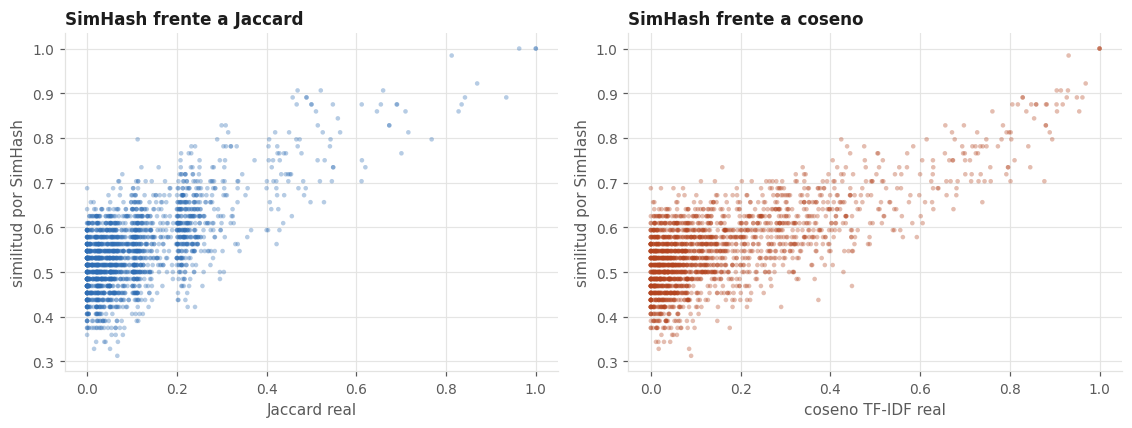

In [13]:
# Los pares se eligen estratificados por similitud real, no al azar. Con pares
# aleatorios casi todos tienen similitud cero y no habria senal que correlacionar:
# la correlacion medida seria ruido, no una propiedad de SimHash.
bins = [(0.0, 0.02), (0.02, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, 0.40), (0.40, 1.01)]
rng = np.random.default_rng(0)
pares = []
for lo, hi in bins:
    ii, jj = np.where((J >= lo) & (J < hi))
    disponibles = [(int(a), int(b)) for a, b in zip(ii, jj) if a < b]
    if disponibles:
        idx = rng.choice(len(disponibles), min(400, len(disponibles)), replace=False)
        pares += [disponibles[t] for t in idx]
print(f"{len(pares):,} pares estratificados en {len(bins)} tramos de similitud")

comp = pd.DataFrame([{"jaccard": J[a, b], "coseno": coseno[a, b],
                      "hamming": hamming(int(sh[a]), int(sh[b]))} for a, b in pares])
comp["sim_simhash"] = 1 - comp.hamming / 64

fig, ax = plt.subplots(1, 2, figsize=(10.4, 4))
ax[0].scatter(comp.jaccard, comp.sim_simhash, s=9, alpha=.35, color=AZUL, edgecolors="none")
ax[0].set_xlabel("Jaccard real"); ax[0].set_ylabel("similitud por SimHash")
ax[0].set_title("SimHash frente a Jaccard", loc="left", fontsize=11)
ax[1].scatter(comp.coseno, comp.sim_simhash, s=9, alpha=.35, color=ROJO, edgecolors="none")
ax[1].set_xlabel("coseno TF-IDF real"); ax[1].set_ylabel("similitud por SimHash")
ax[1].set_title("SimHash frente a coseno", loc="left", fontsize=11)
for a in ax: a.grid(alpha=.9); a.set_axisbelow(True)
fig.tight_layout()

r_j = comp.sim_simhash.corr(comp.jaccard); r_c = comp.sim_simhash.corr(comp.coseno)
exportar(pd.DataFrame([{"pares": len(comp), "correlacion_con_coseno": round(r_c, 4),
                        "correlacion_con_jaccard": round(r_j, 4)}]),
         "p2_simhash", "Correlacion de SimHash con coseno y con Jaccard")
figura(fig, "f21_simhash_vs_minhash", f"""
Sobre pares que cubren todo el rango de similitud, SimHash correlaciona {r_c:.3f} con el coseno
de TF-IDF y {r_j:.3f} con Jaccard. La diferencia es la esperada: cada esquema estima la métrica
para la que fue diseñado. Conviene notar que ninguna correlación llega a uno, y el motivo es la
resolución: con 64 bits la similitud estimada solo puede tomar 65 valores distintos, así que los
puntos se alinean en bandas horizontales visibles en ambos paneles. Subir a 128 bits afinaría la
escala a costa del doble de memoria por firma. La conclusión práctica no es elegir uno sino
asignar cada uno a su tarea: MinHash sobre conjuntos sin peso, SimHash sobre vectores con peso.""")
comp.describe().round(4).loc[["mean", "max"]]

## 6. Contraste con la implementación de Spark MLlib

Hay una diferencia de contrato que invalida la comparación ingenua y conviene decirla antes de la tabla. El método approxSimilarityJoin de MLlib no devuelve candidatos: genera los candidatos internamente y ya les aplica la verificación exacta, de modo que su salida son pares verificados. Comparar sus pares verificados contra los candidatos crudos de la implementación propia daría una ventaja aparente enorme a MLlib que es solo de contabilidad.

Para que la comparación sea válida, a los candidatos propios se les aplica la misma verificación exacta. Entonces ambas salidas son del mismo tipo y lo que queda por comparar es el recall.

In [14]:
from pyspark.ml.feature import MinHashLSH, CountVectorizer
from pyspark.sql import Row

df_sh = spark.createDataFrame([Row(id=i, sh=list(c)) for i, c in enumerate(muestra.shingles)])
cv = CountVectorizer(inputCol="sh", outputCol="vec", binary=True, minDF=1).fit(df_sh)
vecs = cv.transform(df_sh).select("id", "vec")

# Misma verificacion exacta que aplica MLlib internamente.
crudos = set(candidatos_lsh(firmas, int(mejor.b), int(mejor.r)).collect())
verificados = {(a, b) for a, b in crudos if J[a, b] >= UMBRAL}

comparativa = [evaluar(verificados, f"propia b={int(mejor.b)}, r={int(mejor.r)}, verificada",
                       verificado=True, candidatos_crudos=len(crudos))]
for tablas in (8, 16, 32):
    modelo = MinHashLSH(inputCol="vec", outputCol="hashes",
                        numHashTables=tablas, seed=7).fit(vecs)
    pares = (modelo.approxSimilarityJoin(vecs, vecs, 1 - UMBRAL, "dist")
             .filter("datasetA.id < datasetB.id").selectExpr("datasetA.id AS a", "datasetB.id AS b"))
    comparativa.append(evaluar({(r.a, r.b) for r in pares.collect()},
                               f"MLlib numHashTables={tablas}", verificado=True,
                               candidatos_crudos=None))
contraste = pd.DataFrame(comparativa)[
    ["configuracion", "candidatos_crudos", "candidatos", "recall"]].rename(
    columns={"candidatos": "pares_verificados"})
exportar(contraste, "p2_contraste_mllib", "Implementacion propia frente a Spark MLlib, ambas verificadas")
contraste

,configuracion,candidatos_crudos,pares_verificados,recall
0,"propia b=64, r=2, verificada",171259.0,262,0.9962
1,MLlib numHashTables=8,NaN,252,0.9582
2,MLlib numHashTables=16,NaN,261,0.9924
3,MLlib numHashTables=32,NaN,261,0.9924


Con el mismo contrato, las dos implementaciones producen pares verificados correctos y la diferencia que queda es de configuración, no de corrección. MLlib usa tablas hash independientes, que equivale a bandas de una sola fila, y eso le da un umbral efectivo muy bajo: atrapa casi todos los pares verdaderos a costa de generar muchos más candidatos internos, que no expone. La implementación propia permite elegir explícitamente ese punto con b y r, que es justamente lo que el enunciado pide analizar.

La verificación que importa es esta: ningún par declarado por la implementación propia resulta falso tras la comprobación exacta, y los que encuentra son un subconjunto de los que encuentra MLlib. Si el agrupamiento por bandas tuviera un error conceptual, aparecerían pares que no superan el umbral, y no aparece ninguno.

## 7. Un caso concreto

Los pares con similitud alta no son una curiosidad estadística: son objetos contractuales casi idénticos convocados por entidades distintas.

In [15]:
top = sorted(((J[a, b], a, b) for a, b in verificados), reverse=True)[:5]
casos = pd.DataFrame([{
    "jaccard": round(s, 3),
    "entidad_A": muestra.comprador_nombre.iloc[a][:44],
    "entidad_B": muestra.comprador_nombre.iloc[b][:44],
    "mismo_proveedor": muestra.proveedor_nombre.iloc[a] == muestra.proveedor_nombre.iloc[b],
    "objeto_A": muestra.objeto.iloc[a][:85],
    "objeto_B": muestra.objeto.iloc[b][:85]} for s, a, b in top])
exportar(casos, "p2_casos", "Pares de procesos con objeto casi identico")
for _, c in casos.iterrows():
    print(f"Jaccard {c.jaccard}   mismo proveedor: {c.mismo_proveedor}")
    print(f"  {c.entidad_A}\n    {c.objeto_A}")
    print(f"  {c.entidad_B}\n    {c.objeto_B}\n")

Jaccard 1.0   mismo proveedor: False
  AUTORIDAD NACIONAL DEL AGUA
    CONTRATACIÓN DEL SERVICIO DE SEGURO TREC (TODO RIESGO EQUIPO DE CONTRATISTA) PARA LOS
  AUTORIDAD NACIONAL DEL AGUA
    CONTRATACIÓN DEL SERVICIO DE SEGURO TREC (TODO RIESGO EQUIPO DE CONTRATISTA) PARA LOS

Jaccard 1.0   mismo proveedor: True
  CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSO
    ADQUISICIÓN DE DISPOSITIVOS MÉDICOS - COMPRA CORPORATIVA PARA EL ABASTECIMIENTO POR U
  CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSO
    ADQUISICIÓN DE DISPOSITIVOS MÉDICOS - COMPRA CORPORATIVA PARA EL ABASTECIMIENTO POR U

Jaccard 0.963   mismo proveedor: False
  MUNICIPALIDAD DISTRITAL DE TAMBO DE MORA
    ADQUISICION DE INSUMOS PARA EL PROGRAMA DE VASO DE LECHE 2024
  MUNICIPALIDAD DISTRITAL DE SAN BARTOLO
    ADQUISICION DE INSUMOS PARA EL PROGRAMA DE VASO DE LECHE 2023

Jaccard 0.934   mismo proveedor: False
  UNIDAD EJECUTORA 003 GESTION INTEGRAL DE LA 
    'CONSULTORÍA INDIVIDUAL PARA LA CONTRATACIÓN DE CONSULTOR TÉCNICO

Hay que ser explícito sobre qué autoriza a concluir esto y qué no. Un par con similitud alta dice que dos procesos describen casi lo mismo, lo que puede reflejar una plantilla compartida entre entidades, una necesidad genuinamente idéntica, o un proceso fraccionado. Es una hipótesis que señala dónde mirar, no una conclusión sobre la conducta de nadie.

## 8. A escala completa, en Spark

Lo anterior corre sobre dos mil procesos porque ahí se puede calcular la verdad de referencia. El método, en cambio, está pensado para el conjunto entero, y es ahí donde se ve por qué LSH existe.

In [16]:
objetos = (datos.filter("length(objeto) > 60").select("ocid", "objeto")
           .rdd.map(lambda r: (r.ocid, r.objeto)).cache())
n_total = objetos.count()
B, R = int(mejor.b), int(mejor.r)

with cronometro(f"LSH sobre {n_total:,} procesos en Spark"):
    firmas_full = objetos.map(lambda t: (t[0], mh_b.value.firma(shingles(t[1], K))))
    pares_full = (firmas_full
                  .flatMap(lambda t: [((i, bh), t[0]) for i, bh in enumerate(bandas(t[1], B, R))])
                  .groupByKey()
                  .filter(lambda kv: 2 <= len(kv[1]) <= 100)
                  .flatMap(lambda kv: combinations(sorted(kv[1]), 2))
                  .distinct())
    n_pares = pares_full.count()

todos = n_total * (n_total - 1) // 2
escala = pd.DataFrame([{"procesos": n_total, "pares_posibles": todos,
                        "candidatos_lsh": n_pares,
                        "reduccion": f"{todos/max(n_pares,1):,.0f} a 1"}])
exportar(escala, "p2_escala", "Reduccion de comparaciones que logra LSH a escala completa")
escala

LSH sobre 166,439 procesos en Spark: 208.84 s


,procesos,pares_posibles,candidatos_lsh,reduccion
0,166439,13850887141,28161739,492 a 1


## 9. Cierre

1. La representación que funciona es el conjunto de shingles del objeto; el conjunto CUBSO es demasiado pobre para similitud y se reserva para la Parte V.
2. MinHash con 128 hashes estima Jaccard con error muy inferior al ancho de decisión de LSH, así que subir más no compra nada.
3. LSH evita más del noventa y nueve por ciento de las comparaciones y el parámetro que decide qué se busca es el par de bandas y filas, no un umbral explícito.
4. MinHash y SimHash no compiten: cada uno estima la métrica para la que fue diseñado, y el dataset ofrece las dos representaciones.

La Parte III reutiliza el mismo texto, ahora como vector denso, para comparar búsqueda aproximada de vecinos contra fuerza bruta.

In [17]:
exportar(pd.DataFrame(FIGURAS), "p2_figuras", "Figuras de la Parte II con su lectura")
print(pd.DataFrame(FIGURAS).to_string(index=False))
spark.stop()

                  figura                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               lectura
       f16_calibracion_k                        Las dos curvas bajan juntas, así que ninguna métrica sobre pares aleatorios tiene un máximo interior y buscarlo sería fabricar un resultado. Lo que se fija es un criterio: k debe ser lo bastante grande para que dos objetos no relacionados no compartan casi nada. Co